### STEP 1: Import Libraries

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 2: Load Dataset

In [153]:
import pandas as pd

df = pd.read_csv(
    "raw_inequality_data.csv",
    usecols=["AGEP", "SCHL", "PINCP","ESR","ST"],
    nrows=300000
)

print("Shape:", df.shape)

Shape: (300000, 5)


In [154]:
df = df.rename(columns={
    "AGEP": "Age",
    "SCHL": "Educ",
    "PINCP": "Income",
    "ESR": "Employment",
    "ST":"State"
})

In [155]:
df["Employment"] = df["Employment"].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [156]:
print(df.columns)

Index(['State', 'Age', 'Educ', 'Employment', 'Income'], dtype='object')


In [157]:
df.head()

,State,Age,Educ,Employment,Income
0,1,85,19.0,6.0,18800.0
1,1,51,17.0,6.0,12500.0
2,1,36,11.0,6.0,16400.0
3,1,74,1.0,6.0,8600.0
4,1,49,19.0,6.0,5000.0


In [158]:
df.tail()

,State,Age,Educ,Employment,Income
299995,6,64,17.0,6.0,5800.0
299996,6,28,16.0,1.0,60000.0
299997,6,71,16.0,6.0,16400.0
299998,6,72,1.0,6.0,90000.0
299999,6,18,15.0,6.0,0.0


### STEP 3: Data Understanding

In [159]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       300000 non-null  int64  
 1   Age         300000 non-null  int64  
 2   Educ        292476 non-null  float64
 3   Employment  251954 non-null  float64
 4   Income      255737 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 11.4 MB


,State,Age,Educ,Employment,Income
count,300000.000000,300000.000000,292476.000000,251954.000000,2.557370e+05
mean,4.448727,42.532627,16.171871,3.377406,4.609622e+04
std,1.832140,23.828482,5.663440,2.444953,7.476490e+04
min,1.000000,0.000000,1.000000,1.000000,-8.700000e+03
25%,4.000000,22.000000,15.000000,1.000000,6.390000e+03
50%,5.000000,42.000000,18.000000,2.000000,2.500000e+04
75%,6.000000,62.000000,21.000000,6.000000,5.700000e+04
max,6.000000,94.000000,24.000000,6.000000,1.557000e+06


### STEP 4: Data Cleaning

In [160]:
# Select required columns
df = df[["Age", "Educ", "Income","Employment","State"]]

In [161]:
# null values count per column
print(df.isnull().sum())

Age               0
Educ           7524
Income        44263
Employment    48046
State             0
dtype: int64


In [162]:
# total duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 130666


In [165]:
# remove null values
df = df.dropna()

In [164]:
# remove duplicates
df = df.drop_duplicates()

In [166]:
df.isnull().sum()

Age           0
Educ          0
Income        0
Employment    0
State         0
dtype: int64

In [167]:
df.duplicated().sum()

np.int64(0)

In [168]:
print("After cleaning:", df.shape)

After cleaning: (168563, 5)


### STEP 5: Save Cleaned Dataset

In [169]:
df.to_csv("cleaned_inequality_data.csv", index=False)

### STEP 6: EDA (Exploratory Analysis)

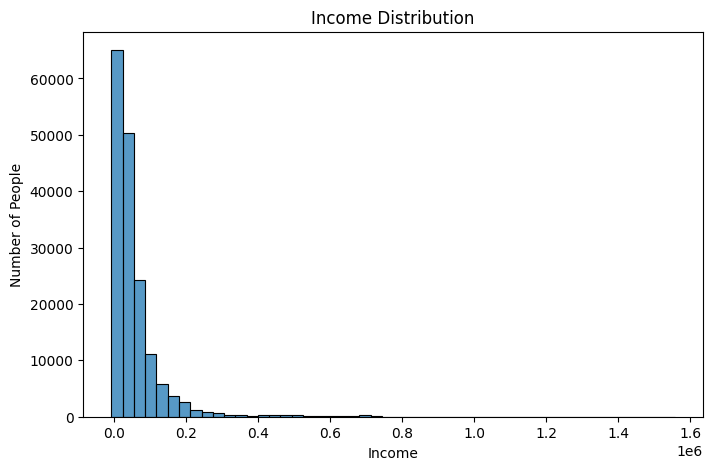

In [170]:
#Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Income"], bins=50)

plt.xlabel("Income")   
plt.ylabel("Number of People")  
plt.title("Income Distribution")

plt.show()

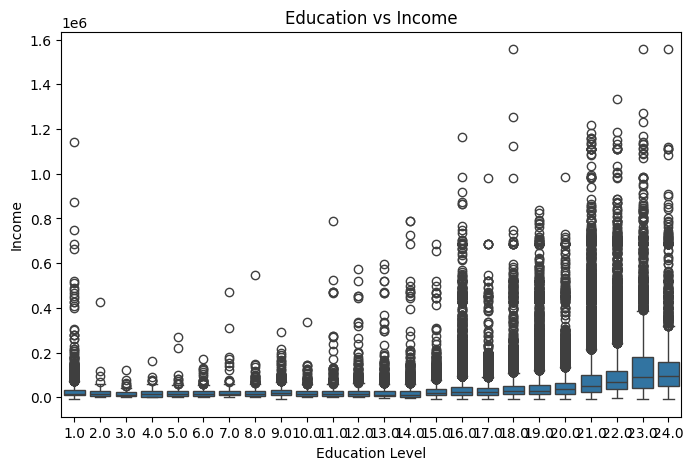

In [171]:
#Education vs Income 
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Educ"], y=df["Income"])

plt.xlabel("Education Level")  
plt.ylabel("Income")         
plt.title("Education vs Income")

plt.show()

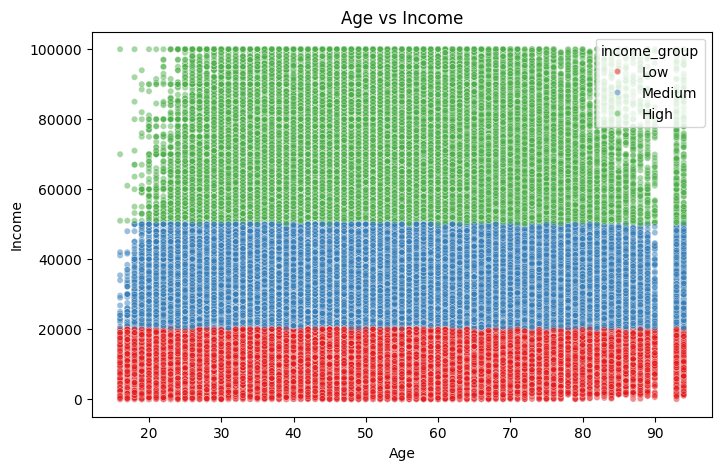

In [175]:
#Age vs Income 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Age"],
    y=df["Income"],
    hue=df["income_group"],
    palette="Set1",
    alpha=0.5,
    s=20
)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income")

plt.show()

In [176]:
df["income_group"] = pd.cut(
    df["Income"],
    bins=[0, 20000, 50000, 100000],
    labels=["Low", "Medium", "High"]
)

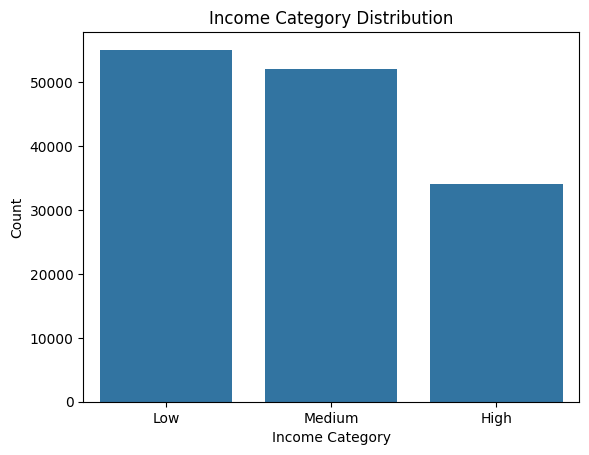

In [177]:
sns.countplot(x=df["income_group"])

plt.xlabel("Income Category")   
plt.ylabel("Count")             
plt.title("Income Category Distribution")

plt.show()

### STEP 7: KPI Calculation

In [178]:
# Poverty rate (income < 20000)
poverty_rate = (df["Income"] < 20000).mean() * 100
print("Poverty Rate:", poverty_rate)

Poverty Rate: 34.5473205863683


In [179]:
# Average income
avg_income = df["Income"].mean()
print("Average Income:", avg_income)

Average Income: 55155.124671487814


In [180]:
# High income percentage
high_income_rate = (df["Income"] > 50000).mean() * 100
print("High Income %:", high_income_rate)

High Income %: 33.50913308377284


### STEP 8: Save Metrics

In [181]:
metrics = pd.DataFrame({
    "metric": ["poverty_rate", "avg_income", "high_income_rate"],
    "value": [poverty_rate, avg_income, high_income_rate]
})

metrics.to_csv("inequality_metrics.csv", index=False)

### STEP 9: Feature Engineering

In [182]:
df["target"] = (df["Income"] > 50000).astype(int)

### STEP 10: Train ML Model

In [184]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[["Age", "Educ", "Employment","State"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7448462017619316


### STEP 11: Save Model

In [185]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

### STEP 12: Prediction Test

In [187]:
sample = [[85, 19,6,6]] 
prediction = model.predict(sample)

if prediction[0] == 1:
    print("High Income")
else:
    print("Low Income")

print("Prediction:", prediction)

Low Income
Prediction: [0]


c:\Users\ELCOT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [188]:
df.tail()


,Age,Educ,Income,Employment,State,income_group,target
299990,20,14.0,2000.0,1.0,6,Low,0
299993,33,13.0,6000.0,1.0,6,Low,0
299995,64,17.0,5800.0,6.0,6,Low,0
299997,71,16.0,16400.0,6.0,6,Low,0
299998,72,1.0,90000.0,6.0,6,High,1


### STEP 13: Insights

In [128]:
insights = """
1. Higher education leads to higher income.
2. Poverty rate is significant in low income groups.
3. Age has moderate impact on income.
"""

with open("insights.txt", "w") as f:
    f.write(insights)

In [189]:
print(df["target"].value_counts())

target
0    112079
1     56484
Name: count, dtype: int64
